<a href="https://colab.research.google.com/github/hsnec2529-max/PDE-transform-OT/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Experiment 3: The Second-Order 1D Wave Equation**

This experiment moves from first-order to second-order hyperbolic PDEs by tackling the classic one-dimensional wave equation. This equation models a vast range of physical phenomena, including the vibrations of a guitar string, pressure waves in a tube, and the propagation of electromagnetic waves in a transmission line.

##**Aim**
To solve the one-dimensional wave equation using the finite difference method with an explicit time-stepping scheme.

##**Objectives**
* To solve the second-order wave equation for a 1D domain with given initial
and boundary conditions.
* To implement the central difference scheme for both time and space derivatives.
* To understand the role of initial displacement and initial velocity.
* To simulate wave propagation and reflection and observe how waves evolve over time.

##**Governing Equation and Discretization**

The second-order, one-dimensional wave equation is given by:

$$ \frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$

where
 is the displacement at position `x` and time `t`, and `c` is the constant wave propagation speed.

To solve this numerically, we use a **central difference** approximation for both derivatives:

* Time Derivative: $\frac{\partial^2 u}{\partial t^2} \approx \frac{u_i^{n+1} - 2u_i^n + u_i^{n-1}}{(\Delta t)^2}$



* Space Derivative: $\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{(\Delta x)^2}$



Substituting these into the governing equation and solving for the future displacement $u_i^{n+1}$
 gives the explicit update formula.

##**Algorithm**
1. **Discretize the Domain**:
* Divide the spatial domain of length L into discrete points using a step size $\Delta x$

* Divide the time domain of total duration T using a time step
$\Delta t$
2. **Stability Check (CFL Condition)**:
* Calculate the **Courant Number**, $C = \frac{c \Delta t}{\Delta x}$.


* For this explicit scheme to be stable, the Courant number must satisfy $C \le 1$
. If $C > 1$
, the numerical solution will grow without bound and become meaningless.
3. **Set Initial Conditions**:
* This is a second-order equation in time, so we need **two** initial conditions:
  1. Initial displacement: $u(x, 0) = f(x)$
  2. Initial velocity: $\frac{\partial u}{\partial t}(x, 0) = g(x)$

4. **Set Boundary Conditions**:
* Assume the boundaries of the domain are fixed (e.g., the ends of a guitar string). This is a Dirichlet boundary condition: $u(0, t) = u(L, t) = 0$
 for all time t.
5. **Time-stepping Loop**:
* The update rule requires information from two previous time steps (`n` and `n-1`). This poses a problem for the very first step (`n=1`), as we don’t have a state at `n=-1`. We use a special formula for the first step derived from the initial velocity condition. For zero initial velocity, this simplifies.
* For all subsequent time steps (`n > 1`), use the main finite difference formula:$$u_i^{n+1} = 2u_i^n - u_i^{n-1} + C^2 \left( u_{i+1}^n - 2u_i^n + u_{i-1}^n \right)$$
6. **Plot and Visualize**:
* After solving for all time steps, plot the wave’s displacement `u(x)` at different time instances to observe its motion and reflection.

##**Application Problem and Python Implementation**
**Problem**: The vibration of a stretched string under tension is governed by the 1D wave equation. We are tasked with modeling the vibration of a string of length `L=1.0m` stretched between two fixed points. The string is given an initial displacement in the shape of a sine wave,$ u(x,0) = \sin(\pi x)$
, but *zero initial velocity*.

Courant Number C = 0.50
CFL condition is satisfied.
x	u^0	u^1	u^2	u^3	u^4
0.00	0.0000	0.0000	0.0000	0.0000	0.0000
0.10	0.3090	0.3052	0.2940	0.2755	0.2504
0.20	0.5878	0.5806	0.5592	0.5241	0.4762
0.30	0.8090	0.7991	0.7697	0.7214	0.6554
0.40	0.9511	0.9394	0.9048	0.8480	0.7705
0.50	1.0000	0.9878	0.9514	0.8917	0.8102
0.60	0.9511	0.9394	0.9048	0.8480	0.7705
0.70	0.8090	0.7991	0.7697	0.7214	0.6554
0.80	0.5878	0.5806	0.5592	0.5241	0.4762
0.90	0.3090	0.3052	0.2940	0.2755	0.2504
1.00	0.0000	0.0000	0.0000	0.0000	0.0000


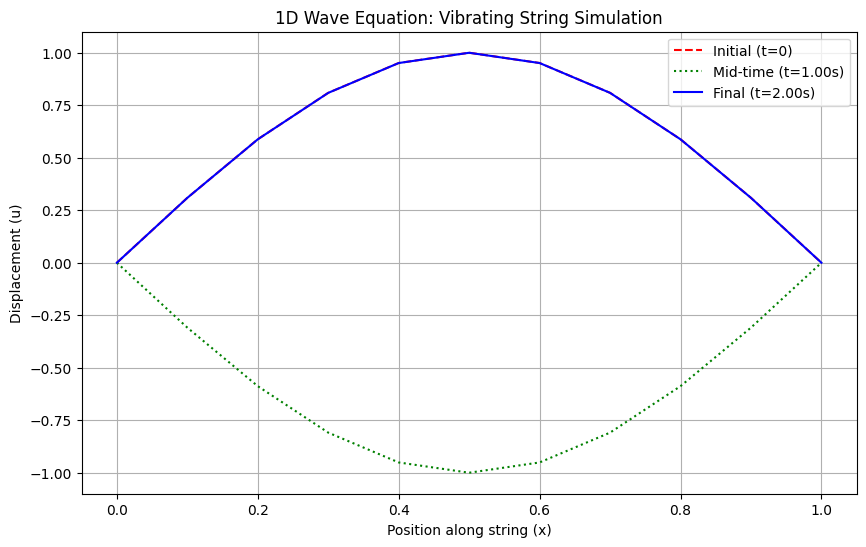

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters & Discretization ---
L = 1.0             # Length of the domain (string)
c = 1.0             # Wave speed
dx = 0.1            # Spatial step size
dt = 0.05           # Time step size
T = 2.0             # Total time (enough for one full reflection)

# --- 2. Stability Check ---
C = c * dt / dx
print(f"Courant Number C = {C:.2f}")
if C > 1:
    raise ValueError("CFL condition (C <= 1) not met. Instability expected.")
else:
    print("CFL condition is satisfied.")

# --- Grid setup ---
x = np.arange(0, L + dx, dx)
nx = len(x)
nt = int(T / dt) + 1
# Create a 2D array to store the solution at all time steps
u = np.zeros((nt, nx))

# --- 3. Initial Conditions ---
# Initial displacement: u(x, 0) = sin(pi * x)
u[0, :] = np.sin(np.pi * x)

# Special formula for the first time step (n=1) assuming zero initial velocity
# u_i^1 = u_i^0 + C^2/2 * (u_{i+1}^0 - 2u_i^0 + u_{i-1}^0)
u[1, 1:-1] = u[0, 1:-1] + 0.5 * C**2 * (u[0, 2:] - 2*u[0, 1:-1] + u[0, :-2])
# Boundary conditions u(0,t)=0 and u(L,t)=0 are already handled by slicing [1:-1]

# --- 5. Time-stepping Loop ---
for n in range(1, nt - 1):
    u[n + 1, 1:-1] = (2 * u[n, 1:-1] - u[n - 1, 1:-1] +
                      C**2 * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2]))
# Print results
print("x\t" + "\t".join([f"u^{n}" for n in range(5)]))  # First 5 steps
for i in range(nx):
    values = "\t".join(f"{u[n, i]:.4f}" for n in range(5))
    print(f"{x[i]:.2f}\t{values}")
# Optional: plot final wave
# --- 6. Plot and Visualize ---
plt.figure(figsize=(10, 6))
plt.plot(x, u[0, :], 'r--', label='Initial (t=0)')
# Time index for t = T/2
mid_time_index = int(nt / 2)
plt.plot(x, u[mid_time_index, :], 'g:', label=f'Mid-time (t={mid_time_index*dt:.2f}s)')
plt.plot(x, u[-1, :], 'b-', label=f'Final (t={T:.2f}s)')

plt.xlabel('Position along string (x)')
plt.ylabel('Displacement (u)')
plt.title('1D Wave Equation: Vibrating String Simulation')
plt.legend()
plt.grid(True)
plt.show()

##**3D plot of the solution of wave equation**

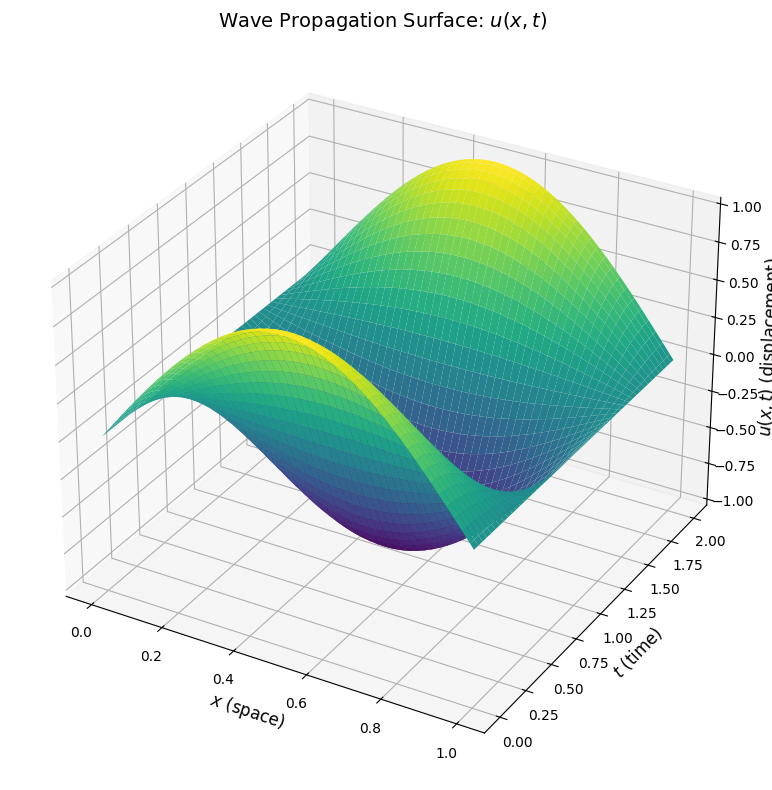

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grid setup
L = 1.0          # Length of domain
T = 2.0          # Total time
c = 1.0          # Wave speed
nx = 100         # Number of spatial points
nt = 200         # Number of time steps
dx = L / (nx - 1)
dt = T / nt
x = np.linspace(0, L, nx)
t = np.linspace(0, T, nt)
C = c * dt / dx  # Courant number

# Check stability
assert C <= 1, f"Stability condition violated: C = {C} > 1"

# Initialize solution matrix
u = np.zeros((nt, nx))

# Initial condition: u(x, 0)
u[0, :] = np.sin(np.pi * x)

# Apply zero initial velocity: u[1, :] from Taylor expansion
u[1, 1:-1] = u[0, 1:-1] + 0.5 * C**2 * (u[0, 2:] - 2*u[0, 1:-1] + u[0, :-2])

# Time stepping
for n in range(1, nt-1):
    u[n+1, 1:-1] = 2*(1 - C**2)*u[n, 1:-1] - u[n-1, 1:-1] + C**2 * (u[n, 2:] + u[n, :-2])
    # Boundary conditions (Dirichlet)
    u[n+1, 0] = 0
    u[n+1, -1] = 0

# Meshgrid for correct 3D plotting
X, T_mesh = np.meshgrid(x, t)

# 3D plot: u(x, t)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, T_mesh, u, cmap='viridis')

ax.set_xlabel('$x$ (space)', fontsize=12)
ax.set_ylabel('$t$ (time)', fontsize=12)
ax.set_zlabel('$u(x,t)$ (displacement)', fontsize=12)
ax.set_title('Wave Propagation Surface: $u(x,t)$', fontsize=14)
plt.tight_layout()
plt.show()

##**Result and Discussion**
The simulation effectively models the behavior of a vibrating string with fixed ends.

* Initial State (`t=0`): The string starts in its initial sine wave shape, as defined.

* Propagation and Reflection: At the mid-time point (`t=1.0s`), the wave has traveled, reflected off the fixed boundaries, and become inverted. This is physically accurate: when a wave on a string hits a fixed end, it reflects back with opposite polarity.

* Final State (`t=2.0s`): After one full period of oscillation, the wave has traveled to both ends, reflected, and returned to its original position and shape, demonstrating the periodic nature of the solution.

* Stability: The CFL number was calculated as $C=0.5$ , which satisfies the stability condition , $C\leq 1$
. This ensures that the solution remains bounded and physically realistic.

* Numerical Dispersion: While not highly prominent in this example due to the smooth initial condition, some slight changes in the wave’s shape might be observed over longer simulation times. This is known as numerical dispersion, an artifact where different frequency components of the wave travel at slightly different speeds in the numerical grid.

**Result**

The explicit finite difference method accurately captures the key dynamics of wave propagation and reflection, making it a powerful tool for analyzing such systems.



##**Application Challenge: Vibration in a Flexible Robot Link**
In modern robotics, lightweight materials are used to create fast and efficient robots. However, these materials are often flexible. When a motor at the base of a robot link starts or stops suddenly, it can induce a longitudinal (compression/expansion) wave that travels down the link, causing vibrations at the end-effector (the robot’s tool or gripper). This vibration can severely impact the robot’s precision.

We can model this phenomenon using the 1D wave equation, where `u(x,t)` now represents the longitudinal displacement of the material from its resting position.

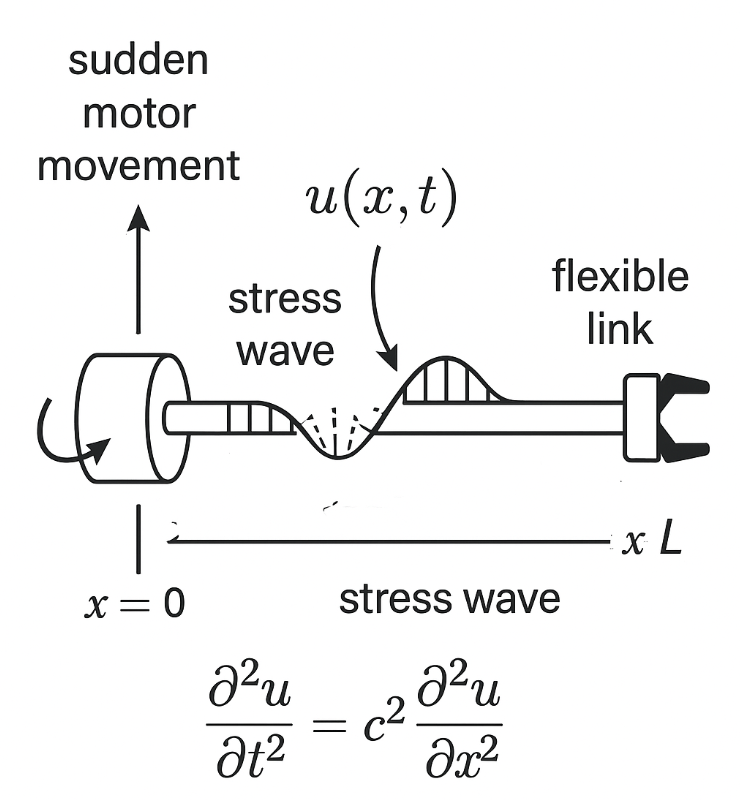


 ### **Your Task :**

Model the vibration in a **2.0-meter long** flexible robot link. * Physical Setup: * Base (x=0): Connected to a motor. We will model a sudden “jolt” by giving the base a brief, sharp displacement and then returning it to zero. * End-Effector (x=L): The end of the link is free to move. This is a Neumann boundary condition, which physically means the stress at the end is zero, or
 $\frac{\partial u}{\partial x}(L, t) = 0$
. * Initial Conditions: The link is initially at rest. * Initial displacement $u(x,0) = 0$
. * Initial velocity $\frac{\partial u}{\partial t}(x,0) = 0$

. * **Wave Speed**: The speed of sound (and thus stress waves) in this material is $c = 50$
 m/s.

###**The Challenge:**
1. *Implement a New Boundary Condition*: The motor’s jolt can be modeled by forcing the displacement at the base, `u[n, 0]`, to be a short pulse. For example, a sine pulse for a very short duration at the beginning of the simulation.
2. *Implement the “Free End” (Neumann) Boundary*: The condition $\frac{\partial u}{\partial x}(L, t) = 0$

 can be approximated with a finite difference as $\frac{u_{nx-1}^n - u_{nx-2}^n}{\Delta x} = 0$
 , which simplifies to $u_{nx-1}^n = u_{nx-2}^n$
. This means the last point always has the same displacement as the point next to it. You must enforce this at every time step.

3. *Analyze the Result*: Plot the displacement of the end-effector `(u[:, -1])`over time to see how it vibrates in response to the motor’s jolt.

###**Hints:**
* Motor Jolt: You can create the motor jolt inside the time-stepping loop. Use an `if` condition to apply the pulse only for a short time (e.g., when `n*dt < pulse_duration`). A simple pulse could be `u[n, 0] = A * np.sin(omega * n * dt)`.

* Neumann Boundary: After the main update loop for the interior points, add a line to enforce the free-end condition: `u[n + 1, -1] = u[n + 1, -2]`. The `-1` index refers to the last element, and `-2` refers to the second-to-last.

* Stability: With a high wave speed (`c=50`), you will need a very small time step `dt` to satisfy the CFL condition ($C \le 1$
). Be prepared to use a large `nt`.

--- Robotics Challenge Parameters ---
Wave Speed c = 50.0 m/s
Courant Number C = 0.90


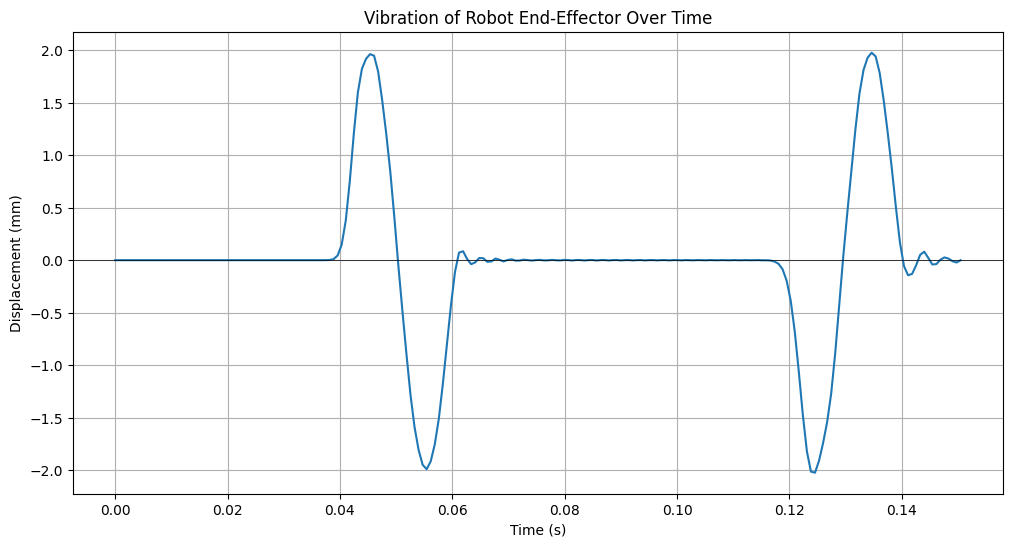

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters for the Robot Link ---
L = 2.0             # Length of the robot link (m)
c = 50.0            # Wave speed in the material (m/s)
T = 0.15            # Total simulation time (s)

# Discretization - fine grid needed for high wave speed
dx = 0.04
# dt must be chosen carefully for stability
dt = dx / c * 0.9   # Choose dt based on dx and c to guarantee C=0.9
C = c * dt / dx

print(f"--- Robotics Challenge Parameters ---")
print(f"Wave Speed c = {c} m/s")
print(f"Courant Number C = {C:.2f}")
if C > 1:
    raise ValueError("CFL condition failed!")

# --- Grid setup ---
x = np.arange(0, L + dx, dx)
t_vec = np.arange(0, T + dt, dt)
nx = len(x)
nt = len(t_vec)
u = np.zeros((nt, nx))

# --- Motor Jolt Parameters ---
pulse_duration = 0.02  # s
pulse_amplitude = 0.001 # 1 mm jolt
pulse_frequency = 2 * np.pi / pulse_duration

# --- 5. Time-stepping Loop with New Boundary Conditions ---
for n in range(1, nt - 1):
    # Main update for interior points (from 2nd point to 2nd-to-last)
    u[n + 1, 1:-1] = (2 * u[n, 1:-1] - u[n - 1, 1:-1] +
                      C**2 * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2]))

    # Boundary Condition 1: Motor Jolt at the Base (x=0)
    current_time = n * dt
    if current_time < pulse_duration:
        u[n + 1, 0] = pulse_amplitude * np.sin(pulse_frequency * current_time)
    else:
        u[n + 1, 0] = 0.0 # Motor holds firm at base after jolt

    # Boundary Condition 2: Free End at x=L (Neumann)
    # u_last = u_second_to_last
    u[n + 1, -1] = u[n + 1, -2]

# --- 6. Plot the End-Effector's Vibration ---
end_effector_displacement = u[:, -1]

plt.figure(figsize=(12, 6))
plt.plot(t_vec, end_effector_displacement * 1000) # Convert to mm
plt.title("Vibration of Robot End-Effector Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (mm)")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5) # Zero line
plt.show()

##**3D plot of the solution**

--- Robotics Challenge Parameters ---
Wave Speed c = 50.0 m/s
Courant Number C = 0.90


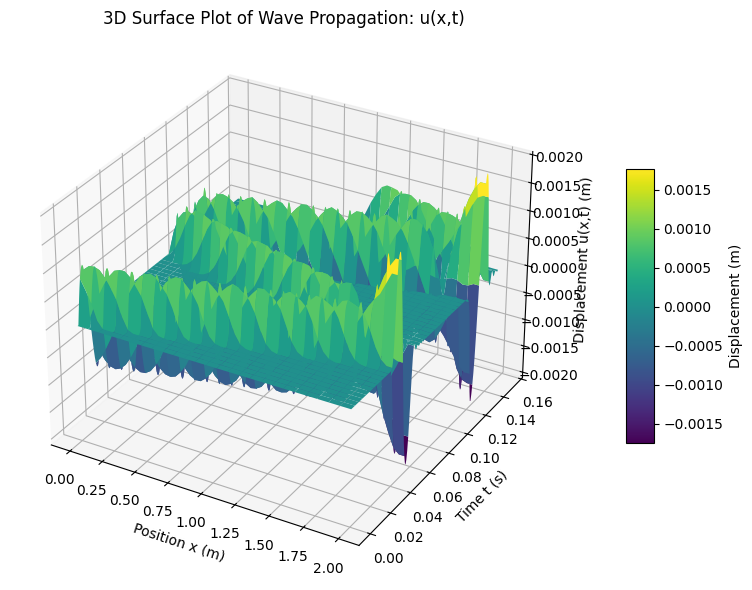

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Parameters for the Robot Link ---
L = 2.0             # Length of the robot link (m)
c = 50.0            # Wave speed in the material (m/s)
T = 0.15            # Total simulation time (s)

# Discretization - fine grid needed for high wave speed
dx = 0.04
dt = dx / c * 0.9   # Choose dt based on dx and c to guarantee C=0.9
C = c * dt / dx

print(f"--- Robotics Challenge Parameters ---")
print(f"Wave Speed c = {c} m/s")
print(f"Courant Number C = {C:.2f}")
if C > 1:
    raise ValueError("CFL condition failed!")

# --- Grid setup ---
x = np.arange(0, L + dx, dx)
t_vec = np.arange(0, T + dt, dt)
nx = len(x)
nt = len(t_vec)
u = np.zeros((nt, nx))

# --- Motor Jolt Parameters ---
pulse_duration = 0.02  # s
pulse_amplitude = 0.001 # 1 mm jolt
pulse_frequency = 2 * np.pi / pulse_duration

# --- 5. Time-stepping Loop with New Boundary Conditions ---
for n in range(1, nt - 1):
    # Main update for interior points (from 2nd point to 2nd-to-last)
    u[n + 1, 1:-1] = (2 * u[n, 1:-1] - u[n - 1, 1:-1] +
                      C**2 * (u[n, 2:] - 2 * u[n, 1:-1] + u[n, :-2]))

    # Boundary Condition 1: Motor Jolt at the Base (x=0)
    current_time = n * dt
    if current_time < pulse_duration:
        u[n + 1, 0] = pulse_amplitude * np.sin(pulse_frequency * current_time)
    else:
        u[n + 1, 0] = 0.0  # Motor holds firm at base after jolt

    # Boundary Condition 2: Free End at x=L (Neumann)
    u[n + 1, -1] = u[n + 1, -2]

# --- 6. 2D Plot: End-Effector's Vibration Over Time ---
end_effector_displacement = u[:, -1]

# --- 7. 3D Surface Plot of u(x,t) ---
X, T_grid = np.meshgrid(x, t_vec)

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, T_grid, u, cmap='viridis', edgecolor='none')

ax.set_title("3D Surface Plot of Wave Propagation: u(x,t)")
ax.set_xlabel("Position x (m)")
ax.set_ylabel("Time t (s)")
ax.set_zlabel("Displacement u(x,t) (m)")
fig.colorbar(surf, shrink=0.5, aspect=10, label='Displacement (m)')
plt.tight_layout()
plt.show()